# Keerukusteooria

Algoritmi keerukus on funktsioon, mis tagastab sisendandmete suuruse $n$ alusel oodatava tööaja või mälukasutuse. Tavaliselt kasutatakse siin suure O funktsiooni, mis taandab keerukuse lihtsale funktsioonile, millele see läheneb piisavalt suure $n$ korral.

Täpsemalt $f(n) = O(g(n))$ tähendab, et on olemas konstandid $c_1$ ja
$c_2$, nõnda, et piisavalt suure $n$ korral:

$$ c_1 g(n) \leq f(n) \leq c_2 g(n)$$ 

Näiteks $$2n^2 - 10n + 10 sin(n) + 40 = O(n^2)$$, sest piisavalt suure $n$ korral
$$ n^2 \leq 2n^2 - 10n + 10 sin(n) + 40 \leq 3 n^2$$
$c_1=1$ ja $c_2=3$ on muidugi ainult üks võimalik väärtustamine.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import pandas as pd

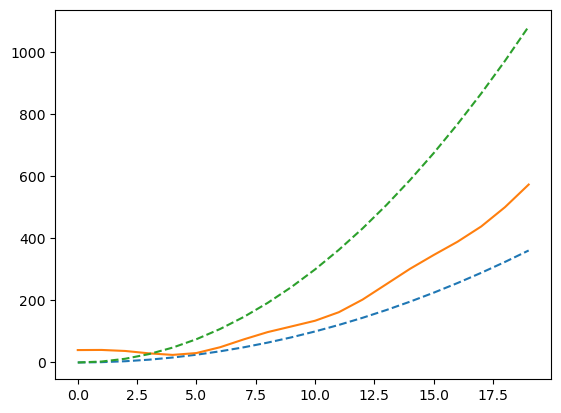

In [2]:
n = np.arange(0, 20)
f_n = 2 * n**2 - 10*n + 10*np.sin(n) + 40
g_n = n**2

plt.plot(n, g_n, linestyle='dashed')
plt.plot(n, f_n)
plt.plot(n, 3*g_n, linestyle='dashed')
plt.show()

Samas $$2n^3 - 10n + 10 sin(n) + 40 \neq O(n^2)$$, sest ükskõik millise 
$c_2$ väärtuse korral,  piisavalt suure $n$ puhul
$$ n^2 \leq 2n^3 - 10n + 10 sin(n) + 40 \nleq c_2 n^2$$

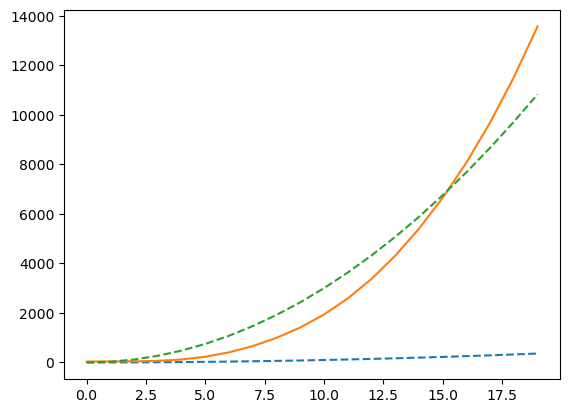

In [3]:
f_n = 2 * n**3 - 10*n +  10*np.sin(n) + 40
g_n = n**2

plt.plot(n, g_n, linestyle='dashed')
plt.plot(n, f_n)
plt.plot(n, 30*g_n, linestyle='dashed')
plt.show()

Korrektne keerukus on siin $O(n^3)$, joonistame graafikud selle jaoks:

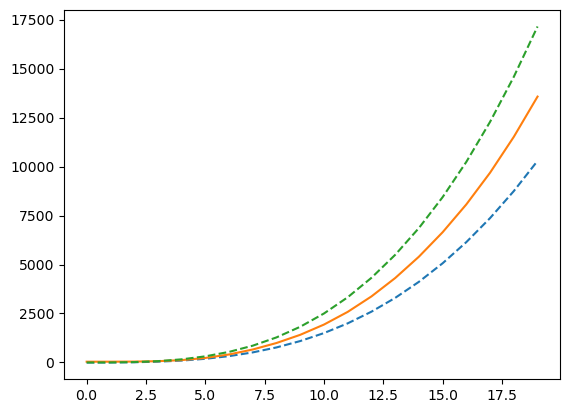

In [4]:
g_n = n**3

plt.plot(n, 1.5 * g_n, linestyle='dashed')
plt.plot(n, f_n)
plt.plot(n, 2.5 * g_n, linestyle='dashed')
plt.show()

## Tüüpkeerukused

Võrdleme tüüpkeerukusi sisendi $n$ kasvades:

In [3]:
n = np.array([1, 2, 5, 10, 20, 50, 100])
table_dict = {"log2 n": np.log2(n), 
         "n": n,
         "n log2 n": n * np.log2(n),
         "n**2": n**2,
         "n**3": n**3,
         "2**n": np.exp2(n),
         "n!": factorial(n)}
table_df = pd.DataFrame(table_dict, index=n)
table_df

[  1   2   5  10  20  50 100]


,log2 n,n,n log2 n,n**2,n**3,2**n,n!
1,0.000000,1,0.000000,1,1,2.000000e+00,1.000000e+00
2,1.000000,2,2.000000,4,8,4.000000e+00,2.000000e+00
5,2.321928,5,11.609640,25,125,3.200000e+01,1.200000e+02
10,3.321928,10,33.219281,100,1000,1.024000e+03,3.628800e+06
20,4.321928,20,86.438562,400,8000,1.048576e+06,2.432902e+18
50,5.643856,50,282.192809,2500,125000,1.125900e+15,3.041409e+64
100,6.643856,100,664.385619,10000,1000000,1.267651e+30,9.332622e+157


Algoritmide keerukusfunktsioonid võib jagada polünomiaalseteks ($n^k$ jms) ja mittepolünomiaalseteks (eksponentsiaalne, faktoriaalne).

Eristatakse ka ülesannete keerukusklasse: P, NP, NP-täielik jne. Siin kerkib muidugi küsimus, kuidas me teame, mis on parima keerukusega algoritm ülesande lahendamiseks? Üks võte on teisendada üks ülesanne polünomiaalse vms keerukusega teisendusalgoritmi abil teiseks ülesandeks, demonstreerides nõnda ülesannete kuulumist samasse keerukusklassi. Selliste klasside omavahelise ekvivalentsuse [P=NP?](https://en.wikipedia.org/wiki/P_versus_NP_problem) küsimus on vast suurim lahendamata probleem arvutiteaduses.

Tüüpiliselt antakse O notatsioonis keerukus kõige halvema juhu tarbeks.
Järgnevas tabelis on toodud mõningate meetodite tüüpiliste algoritmide keerukused:

| Algoritm         | Treenimise keerukus   | Ennustuse keerukus     | 
|------------------|-----------------------|------------------------|
| Otsustuspuu      | $O(n^2 p)$            | $O(p)$                 |
| Juhuslik mets    | $O(n^2 p n_{trees})$  | $O(p n_{trees})$       |
| Gradient Boost   | $O(n p n_{trees})$    | $O(p n_{trees})$       |
| Lineaarne regr.  | $O(p^2 n + p^3)$      | $O(p)$                 |
| Närvivõrk        | $O(n_{neurons}^5)$    | $O(n_{neurons}^4)$     |
| Logistiline regr.| $O(p^2 n + p^3)$      | $O(p)$                 |
| PCA              | $O(p^2 n + p^3)$      |   -                    |
| K-means          | $O(n^{(k+2/p)})$      |   -                    |

Algoritmide keerukuste tabel. $n$ on ridade arv, $p$ on atribuutide arv, $n_{trees}$ on puude arv, $n_{neurons}$ on kihtide ja neuronite arv spetsiifilises närvivõrgu arhitektuuris, kus need on võrdsed.

## Eksperimentaalsed tulemused

In [6]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from timeit import timeit

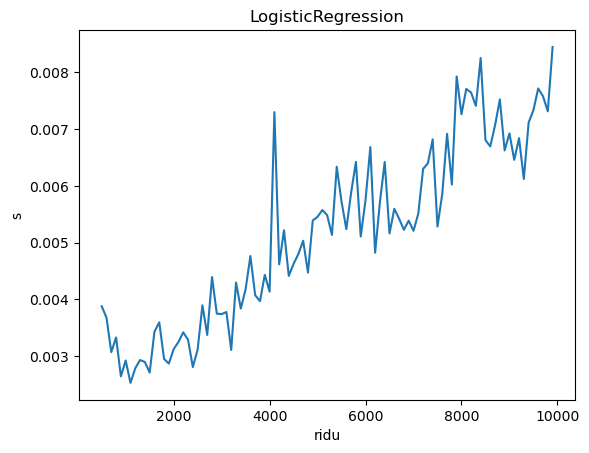

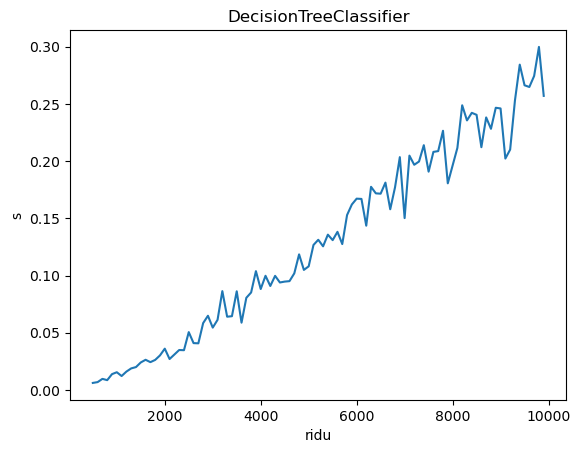

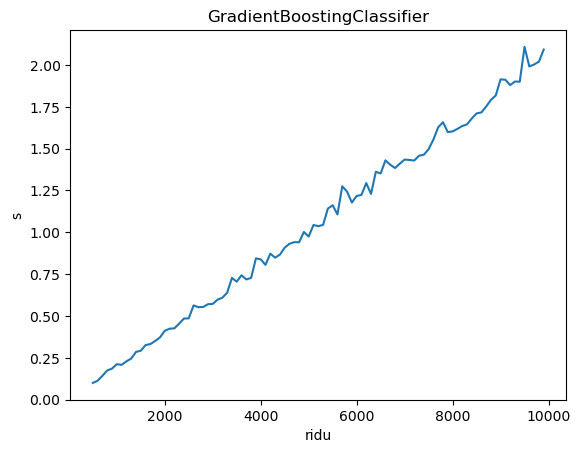

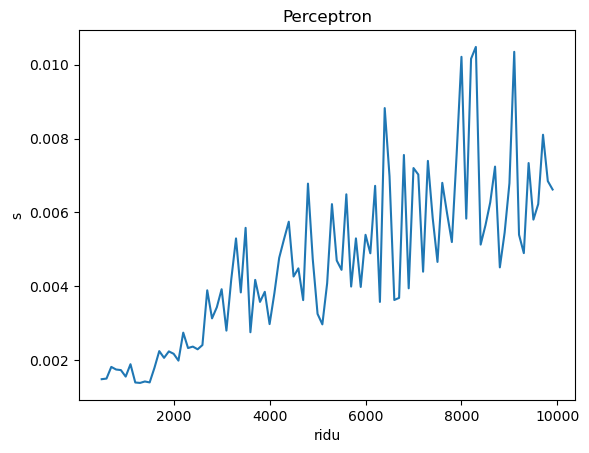

In [10]:
# Kuva seos ridade arvuga kasutades genereeritud struktuurseid andmeid

clfs = [LogisticRegression(max_iter=500, solver='lbfgs'), 
        DecisionTreeClassifier(), 
        GradientBoostingClassifier(n_estimators=20),
        Perceptron(max_iter=500, tol=0.001)]
n_range = range(500, 10000, 100)
for clf in clfs:
    t_range = []
    for n in n_range:
        X, y = make_classification(n_samples=n)
        t_range.append(timeit(lambda : clf.fit(X, y), number=1))

    plt.plot(n_range, t_range)
    plt.title(clf.__class__.__name__)
    plt.xlabel("ridu")
    plt.ylabel("s")
    plt.show()
    

Seos ridade arvuga on küllaltki lineaarne, ansambelõppe meetod *GradientBoost* on ootuspäraselt aeglaseim.

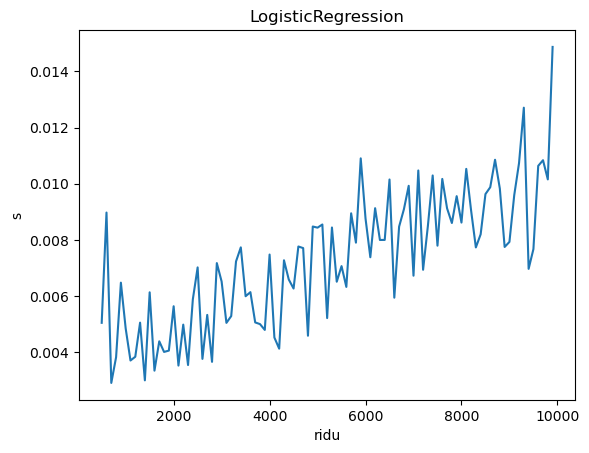

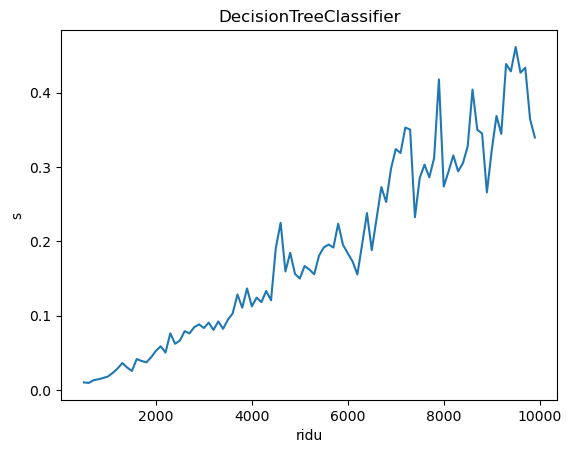

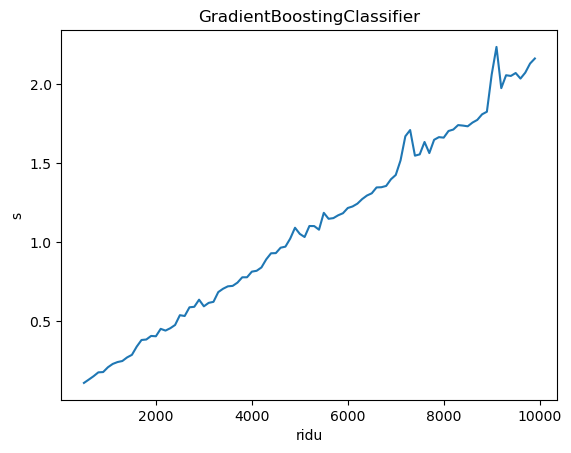

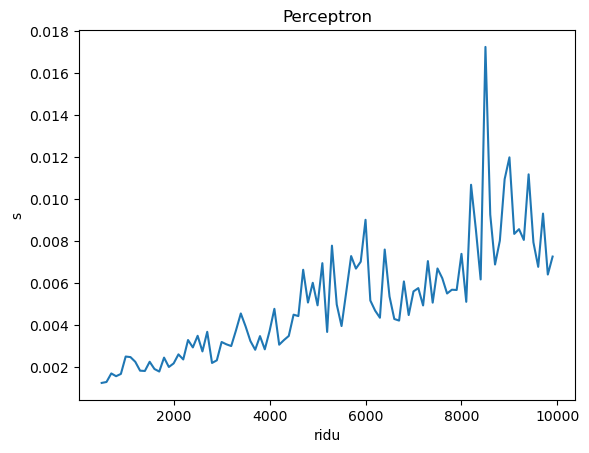

In [11]:
# Kuva seos ridade arvuga kasutades genereeritud juhuslikke andmeid

for clf in clfs:
    t_range = []
    for n in n_range:
        X = np.random.ranf((n, 20))
        y = np.random.randint(low=0, high=2, size=(n,))
        t_range.append(timeit(lambda : clf.fit(X, y), number=1))

    plt.plot(n_range, t_range)
    plt.title(clf.__class__.__name__)
    plt.xlabel("ridu")
    plt.ylabel("s")
    plt.show()

Juhuslike andmete korral on tulemused suuresti samal, tööaeg on struktuursete andmetega võrreldes veidi aeglasem.

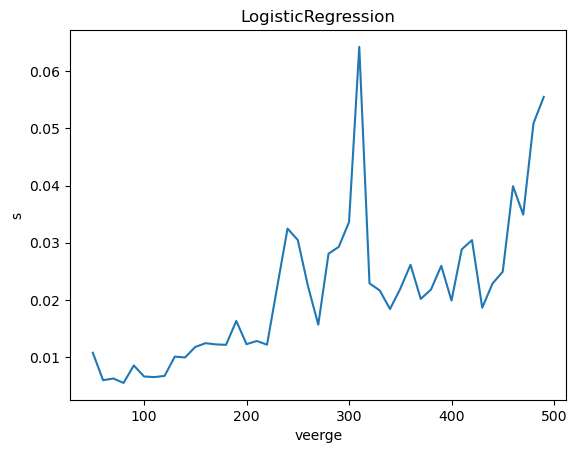

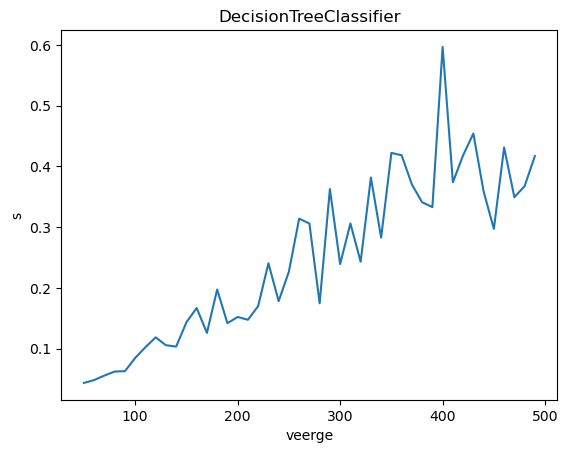

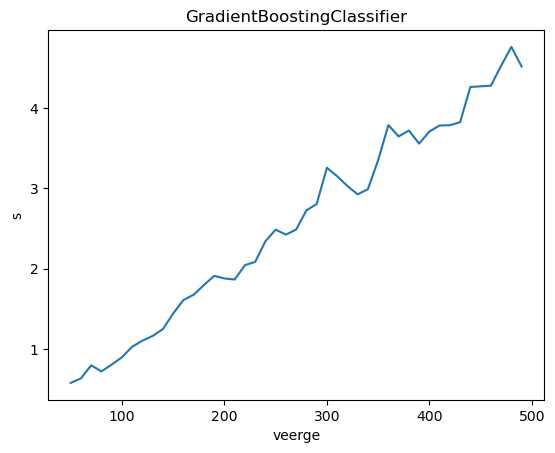

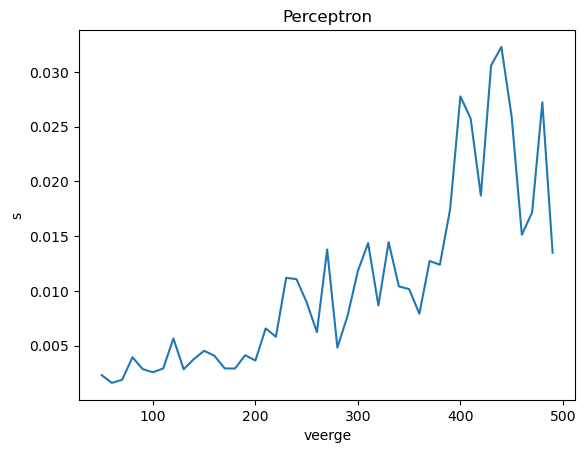

In [12]:
# Kuva seos veergude arvuga kasutades genereeritud struktuurseid andmeid

p_range = range(50, 500, 10)
for clf in clfs:
    t_range = []
    for p in p_range:
        X, y = make_classification(n_samples=1000, n_features=p, n_informative=10)
        t_range.append(timeit(lambda : clf.fit(X, y), number=1))

    plt.plot(p_range, t_range)
    plt.title(clf.__class__.__name__)
    plt.xlabel("veerge")
    plt.ylabel("s")
    plt.show()

Pertseptroni ja logistilise regressiooni tööaeg on veergude arvust sõltuv mittelineaarselt.

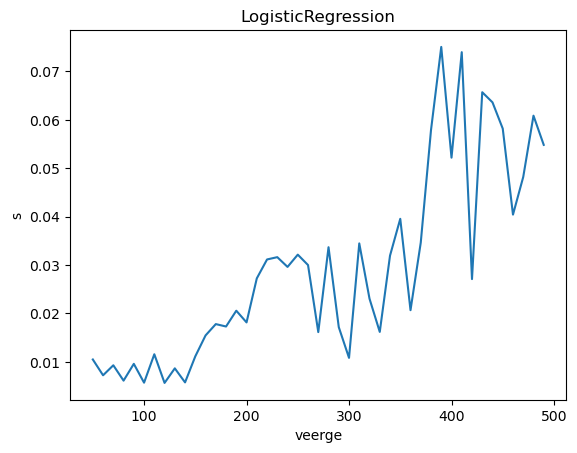

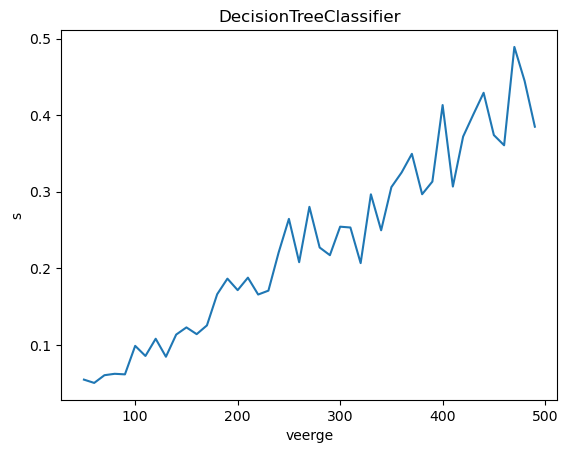

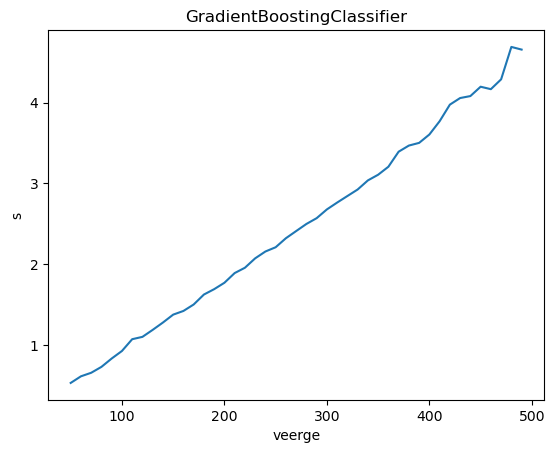

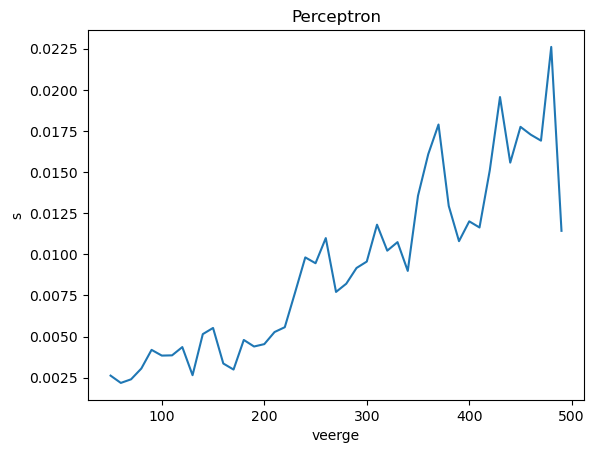

In [13]:
# Kuva seos veergude arvuga kasutades genereeritud juhuslikke andmeid

p_range = range(50, 500, 10)
for clf in clfs:
    t_range = []
    for p in p_range:
        X = np.random.ranf((1000, p))
        y = np.random.randint(low=0, high=2, size=(1000,))
       # X, y = make_classification(n_samples=1000, n_features=p, n_informative=p//10)
        t_range.append(timeit(lambda : clf.fit(X, y), number=1))

    plt.plot(p_range, t_range)
    plt.title(clf.__class__.__name__)
    plt.xlabel("veerge")
    plt.ylabel("s")
    plt.show()

Pertseptroni ja logistilise regressiooni tööaeg on veergude arvust sõltuv mittelineaarselt.

### Struktuursed ja juhuslikud andmed KMeans klasterdamise näitel

In [14]:
from sklearn.cluster import KMeans

X_rnd = np.random.ranf((10000, 10))
km = KMeans(n_clusters=3, n_init=10)
t_rnd = timeit(lambda : km.fit(X_rnd), number=1)
print("KMeans tööaeg juhuslike andmete korral:", t_rnd)

KMeans tööaeg juhuslike andmete korral: 0.8029338000000052


In [15]:
from sklearn.datasets import make_blobs
X_3blobs, y = make_blobs(n_samples=10000, n_features=10, centers=3)
t_3blobs = timeit(lambda : km.fit(X_3blobs), number=1)
print("KMeans tööaeg kolme pilvekese korral:", t_3blobs)

KMeans tööaeg kolme pilvekese korral: 0.6610481000000163


Sobivalt struktureeritud andmete korral on KMeans tööaeg oluliselt kiirem kui juhuslike andmete korral.

### Struktuursed ja juhuslikud andmed otsustuspuu klassifitseerimise näitel

In [16]:
from sklearn.datasets import make_moons
t_noise = []
noise = np.arange(0.0, 1.1, 0.1)
for noise_i in noise:
    X_noisy_moons, y_noisy_moons = make_moons(n_samples=10000, noise=noise_i, random_state=0)
    clf = DecisionTreeClassifier()
    t_i = timeit(lambda : clf.fit(X_noisy_moons, y_noisy_moons), number=1)
    t_noise.append(t_i)
    print("DT tööaeg müra=%.1f andmete korral: %.4f" % (noise_i, t_i))

DT tööaeg müra=0.0 andmete korral: 0.0066
DT tööaeg müra=0.1 andmete korral: 0.0124
DT tööaeg müra=0.2 andmete korral: 0.0178
DT tööaeg müra=0.3 andmete korral: 0.0256
DT tööaeg müra=0.4 andmete korral: 0.0273
DT tööaeg müra=0.5 andmete korral: 0.0308
DT tööaeg müra=0.6 andmete korral: 0.0450
DT tööaeg müra=0.7 andmete korral: 0.0416
DT tööaeg müra=0.8 andmete korral: 0.0348
DT tööaeg müra=0.9 andmete korral: 0.0355
DT tööaeg müra=1.0 andmete korral: 0.0391


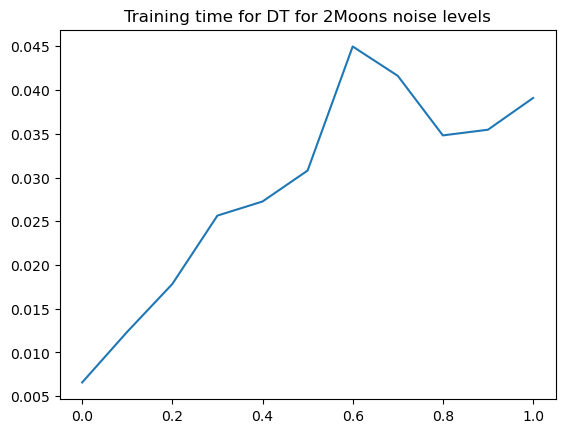

In [17]:
plt.plot(noise, t_noise)
plt.title("Training time for DT for 2Moons noise levels")
plt.show()

## Paralleliseerimine

Tänapäeval on suurandmete analüüsiks kasutusel arvutiklastrid, mis põhinevad graafikakaartidel (GPU: Graphics Processing Unit), mis suudavad paralleelselt teostada suurt hulka lihtsaid arvutusi. Nagu nägime, siis õige algoritmi valik võib omada astronoomilist mõju ja on seega prioriteetsem kui massiivselt võimsa riistvara kasutamine. Võimsama riistvara vajadus tuleb pärast optimaalse algoritmi valikut kui jõudlus pole ikkagi piisav.

Paralleelarvutuste puhul kasutatakse vahel klassi NC mõistet. Probleem kuulub klassi NC kui seda ei ole võimalik lahendada polünomiaalse ajaga kasutaded kõige rohkem polünomiaalset arvu protsessoreid.